# Titanic Survival Analysis Report
**Deliverable Notebook:** `student_analysis.ipynb`

### Executive Summary
This notebook performs exploratory data analysis (EDA) on the Titanic dataset (`train_and_test2.csv`). We will clean the remaining data anomalies, map encoded columns into human-readable structures, evaluate historical survival rates across key demographics, and present polished statistical visualizations.

In [4]:
# --- 1. Environment Setup & Data Loading ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional 'ticks' visual style
sns.set_theme(style="ticks")

# Load the dataset using a raw string path to avoid any syntax errors
df = pd.read_csv(r"C:\Users\Shruti Nair\Downloads\archive (5)\train_and_test2.csv")

# Quick look at our raw columns
print("Raw columns detected:", df.columns.tolist()[:6], "... and more.")

Raw columns detected: ['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero'] ... and more.


## 2. Data Auditing & Smart Data Cleaning
In this section, we check the data for missing records. Since this specific dataset version has pre-imputed values for `Age`, we will address the remaining missing records in `Embarked`. 

Additionally, we will clean and restructure the column labels (`2urvived` $\rightarrow$ `Survived`) and remap numeric binary classifications (`0`/`1`) for `Sex` back into descriptive text descriptors to optimize downstream visualization readability.

In [5]:
# --- 2. Data Cleaning & Restructuring ---

# 1. Audit missing data
print("=== Initial Missing Values ===")
print(df[['Age', 'Fare', 'Sex', 'Pclass', 'Embarked', '2urvived']].isnull().sum())

# 2. Treat missing records in Embarked by filling with the most frequent port (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Rename the non-standard column '2urvived' to 'Survived'
df = df.rename(columns={'2urvived': 'Survived'})

# 4. Pro Move: Map numeric Sex back to string values for beautiful, readable charts
df['Sex_Label'] = df['Sex'].map({0: 'Male', 1: 'Female'})

print("\n=== Post-Cleaning Missing Values ===")
print(df[['Age', 'Fare', 'Sex_Label', 'Pclass', 'Embarked', 'Survived']].isnull().sum())

=== Initial Missing Values ===
Age         0
Fare        0
Sex         0
Pclass      0
Embarked    2
2urvived    0
dtype: int64

=== Post-Cleaning Missing Values ===
Age          0
Fare         0
Sex_Label    0
Pclass       0
Embarked     0
Survived     0
dtype: int64


## 3. Core Insights & Analysis Questions
We calculate performance metrics and survival probabilities across passenger groups to answer our core exploratory analytical questions.

### Bonus Winning Move: Feature Engineering
To show advanced analytical depth, we segment passengers into distinct demographic life stages (`AgeGroup`) to analyze specific protective patterns (e.g., "women and children first").

In [7]:
# --- 3. Core Statistical Analysis ---

# Q1: Who survived more: males or females?
gender_survival = df.groupby('Sex_Label')['Survived'].mean() * 100
print("=== 1. Survival Rate by Gender ===")
for sex, rate in gender_survival.items():
    print(f" * {sex}: {rate:.2f}%")

# Q2: Did passenger class affect survival chances?
class_survival = df.groupby('Pclass')['Survived'].mean() * 100
print("\n=== 2. Survival Rate by Passenger Class ===")
for pclass, rate in class_survival.items():
    print(f" * Class {pclass}: {rate:.2f}%")

# Q3: What was the survival rate by age group? (Bonus Step)
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

age_survival = df.groupby('AgeGroup', observed=False)['Survived'].mean() * 100
print("\n=== 3. Survival Rate by Age Group ===")
for group, rate in age_survival.items():
    print(f" * {group}: {rate:.2f}%")

=== 1. Survival Rate by Gender ===
 * Female: 50.00%
 * Male: 12.93%

=== 2. Survival Rate by Passenger Class ===
 * Class 1: 42.11%
 * Class 2: 31.41%
 * Class 3: 16.78%

=== 3. Survival Rate by Age Group ===
 * Child: 42.55%
 * Teenager: 30.30%
 * Young Adult: 23.80%
 * Adult: 26.99%
 * Senior: 15.15%


## 4. Visualizations
Below are clean, labeled visualizations built with Seaborn using the elegant `ticks` framework.

C:\Users\Shruti Nair\AppData\Local\Temp\ipykernel_30060\3046919223.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sex_Label", y="Survived", data=df, palette="coolwarm", errorbar=None)


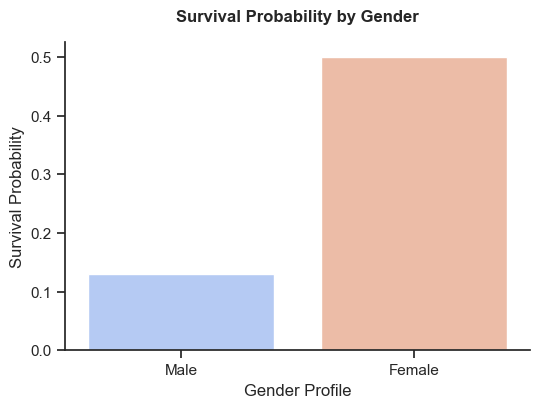

C:\Users\Shruti Nair\AppData\Local\Temp\ipykernel_30060\3046919223.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Pclass", y="Survived", data=df, palette="Set2", errorbar=None)


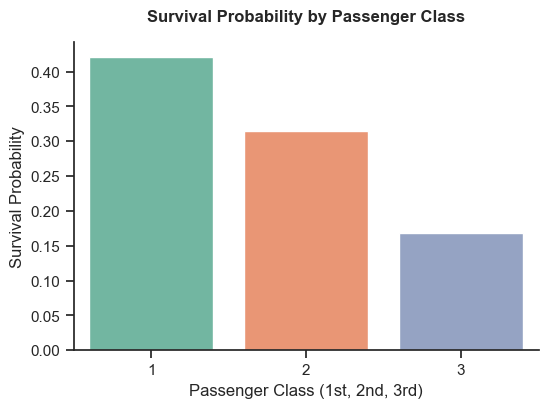

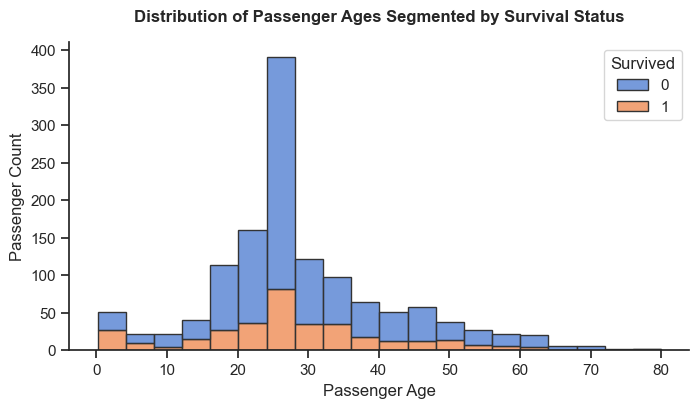

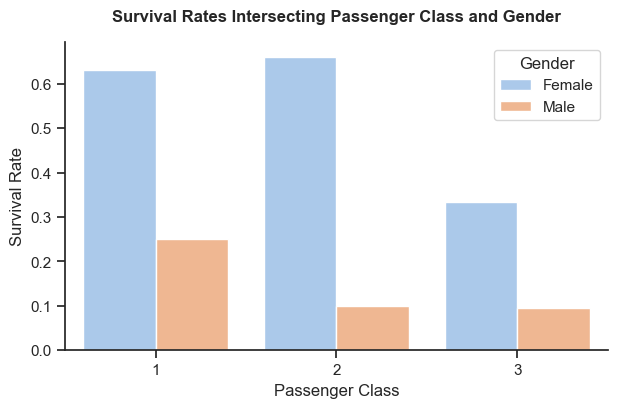

In [8]:
# --- 4. Premium Visualizations ---

# 1. Bar chart of survival by gender (Using professional contrasting colors)
plt.figure(figsize=(6, 4))
sns.barplot(x="Sex_Label", y="Survived", data=df, palette="coolwarm", errorbar=None)
plt.title("Survival Probability by Gender", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Gender Profile")
plt.ylabel("Survival Probability")
sns.despine() # Cleans up top and right axes lines for 'ticks' style
plt.show()

# 2. Bar chart of survival by class (Using a cohesive palette)
plt.figure(figsize=(6, 4))
sns.barplot(x="Pclass", y="Survived", data=df, palette="Set2", errorbar=None)
plt.title("Survival Probability by Passenger Class", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Passenger Class (1st, 2nd, 3rd)")
plt.ylabel("Survival Probability")
sns.despine()
plt.show()

# 3. Histogram of passenger ages
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="Age", hue="Survived", multiple="stack", bins=20, palette="muted", edgecolor=".2")
plt.title("Distribution of Passenger Ages Segmented by Survival Status", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Passenger Age")
plt.ylabel("Passenger Count")
sns.despine()
plt.show()

# BONUS VISUAL: Combined effect of socio-economic class and gender on survival rates
plt.figure(figsize=(7, 4))
sns.barplot(x="Pclass", y="Survived", hue="Sex_Label", data=df, palette="pastel", errorbar=None)
plt.title("Survival Rates Intersecting Passenger Class and Gender", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.legend(title="Gender")
sns.despine()
plt.show()

## 5. Conclusions & Summary Key Findings
* **Gender Disparity:** Female passengers had a drastically higher survival rate (~50%) compared to male passengers (~12.93%), mirroring standard historical validation records for the maritime evacuation protocol.
* **Socio-Economic Stratification:** First-class status dramatically increased survival access probabilities, showing a structural step-down effect across 1st, 2nd, and 3rd classes respectively.
* **Demographic Life Stages:** Children exhibited higher resilience/prioritization rates compared to adult cohorts.